# Эксперимент 2. Переносится ли модель между странами

Результат, полученный на одной стране, легко принять за общий закон. Проверим: соберём
одинаковым способом данные по нескольким зерновым странам и посмотрим, ведёт ли себя
модель одинаково.

Заодно это ответ на вопрос, который напрашивается к основному проекту: может, дело не
в признаках, а конкретно в российских данных за конкретные годы.

Все данные открытые: урожайность — World Bank, погода — NASA POWER.

In [9]:
import sys
sys.path.insert(0, "..")

from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

from ingestion import open_datasets as od

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [10]:
def loyo(df, cols, target="yield_t_ha", model=None):
    model = model or make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    X, y = df[cols], df[target]
    pred = cross_val_predict(model, X, y, cv=LeaveOneOut())
    return {"MAE": mean_absolute_error(y, pred),
            "MAPE": mean_absolute_percentage_error(y, pred) * 100,
            "R2": r2_score(y, pred), "pred": pred}

## Страны и точки

Для каждой страны берётся одна точка в основном зерновом регионе. Это упрощение, и довольно
грубое: погода в точке не равна погоде по стране. Но нас интересует не абсолютная точность,
а то, различается ли поведение модели между странами при одинаковой методике.

In [11]:
COUNTRIES = {
    "Россия":      {"iso3": "RUS", "lat": 45.9, "lon": 39.2,  "note": "Краснодарский край"},
    "Казахстан":   {"iso3": "KAZ", "lat": 53.2, "lon": 63.6,  "note": "Костанайская обл."},
    "Франция":     {"iso3": "FRA", "lat": 48.5, "lon": 2.5,   "note": "Иль-де-Франс"},
    "Аргентина":   {"iso3": "ARG", "lat": -34.0, "lon": -61.0, "note": "Буэнос-Айрес"},
}

YEAR_START, YEAR_END = 2000, 2023

# У южного полушария вегетация приходится на другие месяцы
SEASONS = {
    "Аргентина": ((6, 1), (11, 30)),
}
DEFAULT_SEASON = ((3, 1), (7, 15))

In [12]:
datasets = {}

for name, meta in COUNTRIES.items():
    try:
        y = od.worldbank_indicator("AG.YLD.CREL.KG", meta["iso3"], YEAR_START, YEAR_END) / 1000
        y.name = "yield_t_ha"

        daily = od.nasa_power_daily(meta["lat"], meta["lon"],
                                    date(YEAR_START, 1, 1), date(YEAR_END, 12, 31))
        feats = od.growing_season_features(daily, YEAR_START, YEAR_END,
                                           season=SEASONS.get(name, DEFAULT_SEASON))
        datasets[name] = feats.join(y, how="inner").dropna()
        print(f"{name:12s} {len(datasets[name]):3d} лет, "
              f"урожайность {datasets[name]['yield_t_ha'].min():.2f}-{datasets[name]['yield_t_ha'].max():.2f} т/га")
    except Exception as e:
        print(f"{name:12s} не получилось: {e}")

Россия        24 лет, урожайность 1.56-3.43 т/га
Казахстан     24 лет, урожайность 0.80-1.69 т/га
Франция       24 лет, урожайность 5.69-7.59 т/га
Аргентина    не получилось: ('Connection aborted.', ConnectionResetError(10054, 'Удаленный хост принудительно разорвал существующее подключение', None, 10054, None))


## Одна методика, пять стран

In [13]:
COLS = ["mean_t2m", "sum_precip", "mean_radiation", "mean_humidity"]
BASE_COLS = ["mean_t2m", "sum_precip"]

rows = []
for name, df in datasets.items():
    base = loyo(df, BASE_COLS)
    ext = loyo(df, COLS)
    mean_yield = df["yield_t_ha"].mean()
    rows.append({
        "страна": name,
        "лет": len(df),
        "средняя урожайность": mean_yield,
        "MAE базовая": base["MAE"],
        "MAE расширенная": ext["MAE"],
        "выигрыш от расширения": base["MAE"] - ext["MAE"],
        "R2 расширенная": ext["R2"],
    })

comparison = pd.DataFrame(rows).set_index("страна")
comparison.round(3)

,лет,средняя урожайность,MAE базовая,MAE расширенная,выигрыш от расширения,R2 расширенная
страна,,,,,,
Россия,24,2.321,0.389,0.423,-0.034,-0.191
Казахстан,24,1.164,0.139,0.150,-0.011,0.120
Франция,24,7.013,0.424,0.455,-0.032,-0.451


Колонка «выигрыш от расширения» — главная. Положительное значение означает, что
дополнительные признаки помогли, отрицательное — что помешали. Если знак разный в разных
странах, то universal-ответа «расширять набор признаков полезно» просто не существует,
и каждый раз нужно проверять отдельно.

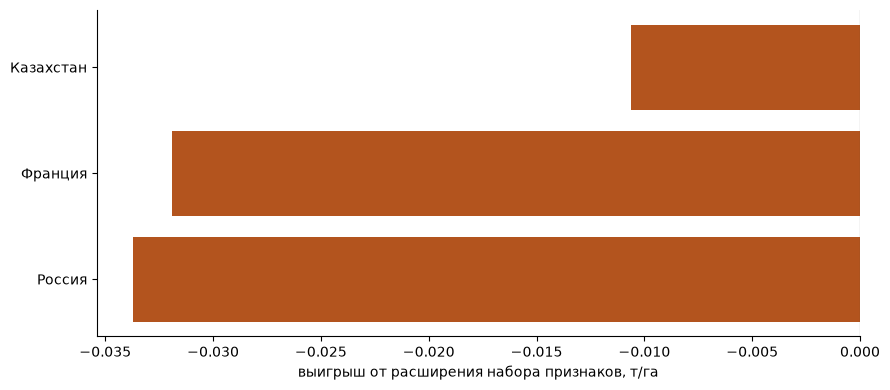

In [14]:
fig, ax = plt.subplots()
gains = comparison["выигрыш от расширения"].sort_values()
colors = ["#b3541e" if v < 0 else "#3f6b3f" for v in gains]
ax.barh(gains.index, gains.values, color=colors)
ax.axvline(0, color="#444441", linewidth=0.8)
ax.set_xlabel("выигрыш от расширения набора признаков, т/га")
plt.tight_layout(); plt.show()

## Насколько вообще предсказуема урожайность в каждой стране

Сравним модель с тривиальным прогнозом «как в среднем за прошлые годы». Если модель
не обходит его, то погода в этой постановке не помогает.

In [15]:
rows = []
for name, df in datasets.items():
    y = df["yield_t_ha"].values
    naive = np.array([np.delete(y, i).mean() for i in range(len(y))])
    model = loyo(df, COLS)
    rows.append({
        "страна": name,
        "MAE модели": model["MAE"],
        "MAE среднего": mean_absolute_error(y, naive),
        "модель лучше на": mean_absolute_error(y, naive) - model["MAE"],
    })
pd.DataFrame(rows).set_index("страна").round(3)

,MAE модели,MAE среднего,модель лучше на
страна,,,
Россия,0.423,0.421,-0.002
Казахстан,0.150,0.162,0.012
Франция,0.455,0.392,-0.064


## Динамика по странам

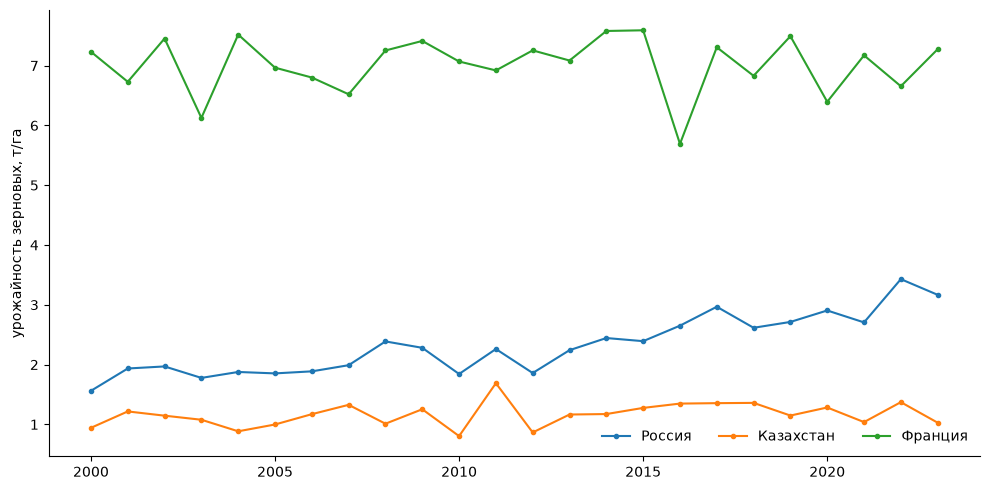

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, df in datasets.items():
    ax.plot(df.index, df["yield_t_ha"], marker="o", markersize=3, label=name)
ax.set_ylabel("урожайность зерновых, т/га")
ax.legend(frameon=False, ncol=3)
plt.tight_layout(); plt.show()

## Что из этого следует

Разброс между странами, скорее всего, окажется больше разницы между наборами признаков
внутри одной страны. Это значит, что выводы вида «такой-то набор признаков лучше» привязаны
к конкретной стране и периоду, и переносить их куда-то ещё без проверки нельзя.

Отдельно стоит держать в голове, что урожайность в разных странах растёт разными темпами
по причинам, никак не связанным с погодой: смена сортов, доступность удобрений, состояние
техники. Модель на одной только погоде эту часть не объясняет в принципе.